<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V12_targeted_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V12 -- Gezielte Transfer-Optimierung: Score-Varianten, Reconstruction Target, Wetter-Test

Dieses Notebook ist an V11 angelehnt, reduziert den Vollvergleich aber bewusst auf wenige gezielte Zusatzexperimente:

1. **Score-Varianten** auf den besten V11-Setups
2. **Reconstruction Target**: Standard vs. nur Demand (`n_lends`, `n_returns`)
3. **Ein einzelner Wetter-Test**

Ziel ist nicht ein neuer Full Grid, sondern eine saubere Analyse, **warum Zero-Shot bereits stark ist und wo noch sinnvoller Hebel liegt**.


In [1]:
# ══════════════════════════════════════════════════════════════
# 0a -- Colab Setup
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ══════════════════════════════════════════════════════════════
# 0b -- Imports
# ══════════════════════════════════════════════════════════════
import os, math, json, random, warnings, time, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass, field, asdict
from typing import List, Optional, Tuple, Dict
from copy import deepcopy
from collections import defaultdict

from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TF: {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")


TF: 2.19.0, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ══════════════════════════════════════════════════════════════
# 0c -- Config + Pfade
# ══════════════════════════════════════════════════════════════
DATA_BASE    = '/content/drive/MyDrive/BA_Colab/data'
CLEANED_BASE = '/content/drive/MyDrive/BA_Colab/cleaned'

RUN_NAME    = 'v12_targeted_transfer'
RESULTS_DIR = f'{DATA_BASE}/{RUN_NAME}'
os.makedirs(RESULTS_DIR, exist_ok=True)

source_demand_path = f'{CLEANED_BASE}/demand/Mannheim/demand_cleaned.parquet'
target_demand_path = f'{CLEANED_BASE}/demand/Heidelberg/demand_cleaned.parquet'
geo_path           = f'{CLEANED_BASE}/geo_information/geo_information.parquet'
station_names_path = f'{DATA_BASE}/station_names/station_names.parquet'

weather_path   = f'{DATA_BASE}/weather'
holidays_path  = f'{DATA_BASE}/holidays'
vacations_path = f'{DATA_BASE}/vacations'

print(f"Results: {RESULTS_DIR}")


Results: /content/drive/MyDrive/BA_Colab/data/v12_targeted_transfer


---
## Schritt 1: V10-Funktionen laden

Alle Shared Functions aus V10 muessen verfuegbar sein. Entweder:
- `%run V10_Transfer_MA_HD.ipynb` ausfuehren, oder
- Die Funktionen aus V10 (Cells 8-19) hier einfuegen

Benoetigte Funktionen: `aggregate_station_level`, `fill_missing_time_bins`,
`prepare_stations_and_splits`, `rolling_context_scores_vectorized`,
`add_rolling_poisson_scores_vectorized`, `calibrate_scores_by_station`,
`percentile_score`, `build_eval_labels_calibrated`, `run_statistical_pipeline`,
`build_lstm_autoencoder`, `train_autoencoder`, `ae_last_step_scores`,
`prepare_city_data`, `run_ae_pipeline`, `TARGETS`, `COUNT_TARGETS`, `add_context_keys`


In [4]:
# ══════════════════════════════════════════════════════════════
# 1 -- V10-Funktionen laden
# ══════════════════════════════════════════════════════════════

# OPTION A: Notebook ausfuehren (empfohlen)
# %run "/content/drive/MyDrive/BA_Colab/V10_Transfer_MA_HD.ipynb"

# OPTION B: Funktionen manuell einfuegen
# (Kopiere V10 Cells 8-19 hier rein)

print("WICHTIG: V10-Funktionen muessen verfuegbar sein!")
print("Entweder per %run oder durch Kopieren aus V10.")


WICHTIG: V10-Funktionen muessen verfuegbar sein!
Entweder per %run oder durch Kopieren aus V10.


---
## Shared Functions (aus V9.2 übernommen)

Alle Kernfunktionen der AD-Pipeline. Identisch zu V9.2 E1.


In [5]:
# ══════════════════════════════════════════════════════════════
# 1 — Aggregation
# ══════════════════════════════════════════════════════════════
def aggregate_station_level(df: pd.DataFrame, minutes: int = 60,
                            add_relative: bool = False) -> pd.DataFrame:
    out = df.copy()
    freq = f"{minutes}min"
    out["time_bin"] = out["timestamp"].dt.floor(freq)

    agg = (
        out.groupby(
            ["station_id", "station_name_id", "station_name", "location_id", "time_bin"],
            as_index=False
        )
        .agg({
            "n_lends": "sum",
            "n_returns": "sum",
            "latitude": "first",
            "longitude": "first"
        })
        .rename(columns={"time_bin": "hour_ts"})
    )

    agg["total_demand"] = agg["n_lends"] + agg["n_returns"]
    agg["net_flow"] = agg["n_returns"] - agg["n_lends"]
    agg["abs_net_flow"] = agg["net_flow"].abs()

    agg["hour"] = agg["hour_ts"].dt.hour
    agg["dow"] = agg["hour_ts"].dt.dayofweek
    agg["month"] = agg["hour_ts"].dt.month
    agg["is_weekend"] = agg["dow"].isin([5, 6]).astype(int)

    agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
    agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)
    agg["dow_sin"]  = np.sin(2 * np.pi * agg["dow"] / 7)
    agg["dow_cos"]  = np.cos(2 * np.pi * agg["dow"] / 7)
    agg["month_sin"] = np.sin(2 * np.pi * (agg["month"] - 1) / 12)
    agg["month_cos"] = np.cos(2 * np.pi * (agg["month"] - 1) / 12)

    agg = agg.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    return agg


In [6]:
# ══════════════════════════════════════════════════════════════
# 2 — Gap-Fill
# ══════════════════════════════════════════════════════════════
def fill_missing_time_bins(x: pd.DataFrame, minutes: int = 60) -> pd.DataFrame:
    freq = f"{minutes}min"
    parts = []
    x = x.copy().sort_values(["station_id", "hour_ts"])
    x = (
        x.groupby(["station_id", "hour_ts"], as_index=False)
         .agg({
             "station_name_id": "first", "station_name": "first",
             "location_id": "first", "latitude": "first",
             "longitude": "first", "n_lends": "sum", "n_returns": "sum",
         })
    )
    key_cols = ["station_id", "station_name_id", "station_name",
                "location_id", "latitude", "longitude"]

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").copy()
        full_idx = pd.date_range(g["hour_ts"].min(), g["hour_ts"].max(), freq=freq)
        g = g.set_index("hour_ts").reindex(full_idx)
        g.index.name = "hour_ts"
        g["n_lends"]   = g["n_lends"].fillna(0).astype(int)
        g["n_returns"] = g["n_returns"].fillna(0).astype(int)
        for col in key_cols:
            g[col] = g[col].ffill().bfill()
        parts.append(g.reset_index())

    result = pd.concat(parts, ignore_index=True)
    result["total_demand"] = result["n_lends"] + result["n_returns"]
    result["net_flow"]     = result["n_returns"] - result["n_lends"]
    result["abs_net_flow"] = result["net_flow"].abs()

    result["hour"] = result["hour_ts"].dt.hour
    result["dow"]  = result["hour_ts"].dt.dayofweek
    result["month"] = result["hour_ts"].dt.month
    result["is_weekend"] = result["dow"].isin([5, 6]).astype(int)

    result["hour_sin"]  = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"]  = np.cos(2 * np.pi * result["hour"] / 24)
    result["dow_sin"]   = np.sin(2 * np.pi * result["dow"] / 7)
    result["dow_cos"]   = np.cos(2 * np.pi * result["dow"] / 7)
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)

    return result.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)


In [7]:
# ══════════════════════════════════════════════════════════════
# 3 — Station-Filter, Demand-Regime, Train/Val/Test Split
# ══════════════════════════════════════════════════════════════
def prepare_stations_and_splits(df: pd.DataFrame, cfg, city_name=""):
    n_days = (df["hour_ts"].max() - df["hour_ts"].min()).days + 1
    min_events = int(n_days * cfg.min_events_per_day)

    station_volume = df.groupby("station_id")["total_demand"].sum()
    active_ids = station_volume[station_volume >= min_events].index.tolist()
    df = df[df["station_id"].isin(active_ids)].copy()

    station_profile = (
        df.groupby(["station_id", "station_name"], as_index=False)
          .agg(
              avg_total_demand_h=("total_demand", "mean"),
              avg_lends_h=("n_lends", "mean"),
              avg_returns_h=("n_returns", "mean"),
              latitude=("latitude", "first"),
              longitude=("longitude", "first")
          )
    )
    q1 = station_profile["avg_total_demand_h"].quantile(cfg.low_demand_q)
    q2 = station_profile["avg_total_demand_h"].quantile(cfg.high_demand_q)
    station_profile["demand_regime"] = station_profile["avg_total_demand_h"].apply(
        lambda x: "low" if x <= q1 else ("mid" if x <= q2 else "high")
    )
    df = df.merge(
        station_profile[["station_id", "demand_regime", "avg_total_demand_h"]],
        on="station_id", how="left"
    )

    t_min = df["hour_ts"].min()
    t_max = df["hour_ts"].max()
    total_h = (t_max - t_min).total_seconds() / 3600

    train_end = t_min + pd.Timedelta(hours=int(total_h * cfg.train_ratio))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * cfg.val_ratio))

    cn = f" ({city_name})" if city_name else ""
    print(f"  Aktive Stationen{cn}: {df['station_id'].nunique()}")
    print(f"  Regime: {station_profile['demand_regime'].value_counts().to_dict()}")
    print(f"  Zeitraum: {t_min.date()} bis {t_max.date()} ({n_days} Tage)")
    print(f"  Split: Train < {train_end.date()}, Val < {val_end.date()}, Test ab {val_end.date()}")

    return df, station_profile, train_end, val_end


In [8]:
# ══════════════════════════════════════════════════════════════
# 4 — Rolling kontextuelle z-Scores
# ══════════════════════════════════════════════════════════════
TARGETS = ["n_lends", "n_returns", "net_flow", "total_demand"]
COUNT_TARGETS = ["n_lends", "n_returns", "total_demand"]

def add_context_keys(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["ctx_hour"] = x["hour_ts"].dt.hour
    x["ctx_dow"]  = x["hour_ts"].dt.dayofweek
    return x

def rolling_context_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    mu_col    = f"{target}_mu_ctx_roll"
    sd_col    = f"{target}_sd_ctx_roll"
    score_col = f"{target}_z_ctx_roll"

    n_slots = max(rolling_days // 7, 4)
    main_window = n_slots
    main_minp   = min(min_obs, main_window)

    grouped = x.groupby(["station_id", "ctx_hour", "ctx_dow"])[target]
    rolling_mean = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).mean()
    )
    rolling_std = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).std(ddof=0)
    )

    fb1_window = n_slots * 2
    fb1_minp   = min(min_obs, fb1_window)
    grouped_sh = x.groupby(["station_id", "ctx_hour"])[target]
    fb1_mean = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).mean()
    )
    fb1_std = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).std(ddof=0)
    )

    fb2_window = n_slots * 4
    fb2_minp   = min(min_obs, fb2_window)
    grouped_s = x.groupby(["station_id"])[target]
    fb2_mean = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).mean()
    )
    fb2_std = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).std(ddof=0)
    )

    mu = rolling_mean.copy()
    sd = rolling_std.copy()
    mask1 = mu.isna()
    mu = mu.where(~mask1, fb1_mean)
    sd = sd.where(~mask1, fb1_std)
    mask2 = mu.isna()
    mu = mu.where(~mask2, fb2_mean)
    sd = sd.where(~mask2, fb2_std)

    sd = sd.clip(lower=1e-6)
    z = (x[target] - mu) / sd

    x[mu_col]    = mu
    x[sd_col]    = sd
    x[score_col] = z
    return x


In [9]:
# ══════════════════════════════════════════════════════════════
# 5 — Poisson-Tail-Scores
# ══════════════════════════════════════════════════════════════
def add_rolling_poisson_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    lam_col       = f"{target}_lambda_ctx_roll"
    score_col     = f"{target}_poisson_upper_score"
    score_low_col = f"{target}_poisson_lower_score"
    mu_col        = f"{target}_mu_ctx_roll"

    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden")

    x[lam_col] = x[mu_col].clip(lower=1e-6)
    vals = x[target].values
    lams = x[lam_col].values

    with np.errstate(divide='ignore', invalid='ignore'):
        tail_p = poisson.sf(vals.astype(float) - 1, lams.astype(float))
        score  = -np.log10(np.clip(tail_p, 1e-12, None))
        lower_p   = poisson.cdf(vals.astype(float), lams.astype(float))
        score_low = -np.log10(np.clip(lower_p, 1e-12, None))

    mask_nan = np.isnan(lams)
    score[mask_nan]     = np.nan
    score_low[mask_nan] = np.nan

    x[score_col]     = score
    x[score_low_col] = score_low
    return x


In [10]:
# ══════════════════════════════════════════════════════════════
# 6 — ECDF-Kalibrierung + Labels
# ══════════════════════════════════════════════════════════════
def percentile_score(train_vals: np.ndarray, values: np.ndarray) -> np.ndarray:
    train_vals = np.asarray(train_vals, dtype=float)
    values     = np.asarray(values, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]
    if len(train_vals) == 0:
        return np.full(len(values), np.nan, dtype=float)
    train_sorted = np.sort(train_vals)
    ranks = np.searchsorted(train_sorted, values, side="right")
    return ranks / len(train_sorted)

def calibrate_scores_by_station(
    full_df: pd.DataFrame, train_mask: pd.Series, raw_score_cols: List[str]
) -> pd.DataFrame:
    x = full_df.copy()
    for col in raw_score_cols:
        if col not in x.columns:
            continue
        pct_col = f"{col}_pct_station"
        x[pct_col] = np.nan
        for sid, grp in x.groupby("station_id", sort=False):
            idx_all   = grp.index
            idx_train = grp.index[train_mask.loc[idx_all]]
            train_vals = x.loc[idx_train, col].to_numpy(dtype=float) if len(idx_train) > 0 else np.array([])
            vals       = x.loc[idx_all, col].to_numpy(dtype=float)
            x.loc[idx_all, pct_col] = percentile_score(train_vals, vals)
    return x

def build_eval_labels_calibrated(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y["label_eval"] = "normal"

    z_up = "total_demand_score_upper_pct_station"
    z_low = "total_demand_score_lower_pct_station"
    p_up  = "total_demand_poisson_upper_score_pct_station"
    p_low = "total_demand_poisson_lower_score_pct_station"

    required = [z_up, z_low, p_up, p_low]
    missing = [c for c in required if c not in y.columns]
    if missing:
        raise ValueError(f"Fehlende Spalten: {missing}")

    td = y["total_demand"].fillna(0)
    mu = y["total_demand_mu_ctx_roll"]

    abs_min_high    = np.maximum(5, np.ceil(mu + 2)).fillna(5)
    abs_min_low_ref = np.maximum(3, np.ceil(mu)).fillna(3)

    high_strong    = ((y[z_up] >= 0.995) | (y[p_up] >= 0.995)) & (td >= abs_min_high)
    high_consensus = ((y[z_up] >= 0.99) & (y[p_up] >= 0.99)) & (td >= abs_min_high)
    cond_high = high_strong | high_consensus

    low_possible  = mu >= abs_min_low_ref
    low_strong    = ((y[z_low] >= 0.999) | (y[p_low] >= 0.999)) & low_possible
    low_consensus = ((y[z_low] >= 0.995) & (y[p_low] >= 0.995)) & low_possible
    cond_low = (low_strong | low_consensus) & ~cond_high

    grau_high = ((y[z_up] >= 0.99) | (y[p_up] >= 0.99)) & ~cond_high & ~cond_low
    grau_low  = ((y[z_low] >= 0.99) | (y[p_low] >= 0.99)) & ~cond_high & ~cond_low & ~grau_high

    y.loc[grau_high, "label_eval"] = "grauzone_high"
    y.loc[grau_low,  "label_eval"] = "grauzone_low"
    y.loc[cond_high, "label_eval"] = "anomal_high"
    y.loc[cond_low,  "label_eval"] = "anomal_low"
    return y


In [11]:
# ══════════════════════════════════════════════════════════════
# 7 — Statistik-Pipeline
# ══════════════════════════════════════════════════════════════
def run_statistical_pipeline(df: pd.DataFrame, cfg, train_end):
    print("  [1/5] Kontext-Keys...")
    df = add_context_keys(df)

    print("  [2/5] Rolling z-Scores...")
    for tgt in TARGETS:
        df = rolling_context_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )
    for tgt in TARGETS:
        zc = f"{tgt}_z_ctx_roll"
        df[f"{tgt}_score_upper"] = df[zc]
        df[f"{tgt}_score_lower"] = -df[zc]

    print("  [3/5] Poisson-Tail-Scores...")
    for tgt in COUNT_TARGETS:
        df = add_rolling_poisson_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )

    print("  [4/5] ECDF-Kalibrierung...")
    raw_score_cols = []
    for tgt in TARGETS:
        raw_score_cols += [f"{tgt}_score_upper", f"{tgt}_score_lower"]
    for tgt in COUNT_TARGETS:
        raw_score_cols += [f"{tgt}_poisson_upper_score", f"{tgt}_poisson_lower_score"]

    train_mask = df["hour_ts"] < train_end
    df = calibrate_scores_by_station(df, train_mask, raw_score_cols)

    print("  [5/5] Labels...")
    df = build_eval_labels_calibrated(df)

    anomaly_rate = df["label_eval"].isin(["anomal_high", "anomal_low"]).mean()
    print(f"  ✓ Label-Verteilung:")
    print(f"    {df['label_eval'].value_counts().to_dict()}")
    print(f"    Anomalie-Rate: {anomaly_rate:.4f} ({anomaly_rate*100:.2f}%)")
    return df


In [12]:
# ══════════════════════════════════════════════════════════════
# 8 -- Sequenzbuilder (erweitert: Window-Level Labels)
# ══════════════════════════════════════════════════════════════
from numpy.lib.stride_tricks import sliding_window_view

def make_sequences_fast(
    x: pd.DataFrame, feature_cols: List[str], window_size: int,
    label_col: Optional[str] = None, require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame, Optional[np.ndarray]]:
    X_parts, meta_parts, y_parts = [], [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win  = sliding_window_view(vals, window_shape=window_size, axis=0)
        win  = np.moveaxis(win, -1, 1)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs  = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]

        X_parts.append(win[valid_mask])
        meta_parts.append(g.iloc[end_indices].copy())

        if label_col is not None:
            y_parts.append(g.iloc[end_indices][label_col].to_numpy())

    if X_parts:
        X    = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
        y    = np.concatenate(y_parts) if y_parts else None
    else:
        X    = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()
        y    = None
    return X, meta, y


def make_sequences_with_window_labels(
    x: pd.DataFrame, feature_cols: List[str], window_size: int,
    synth_label_col: str = "synth_label",
    synth_type_col: str = "synth_type",
    require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame]:
    """
    Wie make_sequences_fast, aber mit korrekten Window-Level Labels.

    Fuer jede Sequenz wird geprueft, ob IRGENDEIN Zeitschritt im Fenster
    synth_label=1 hat. Falls ja: window_synth_label=1.
    Zusaetzlich: synth_type des letzten injizierten Schritts im Fenster.

    Returns:
        X:    (n_sequences, window_size, n_features)
        meta: DataFrame mit Spalten des letzten Zeitschritts +
              window_synth_label, window_synth_type, n_synth_in_window
    """
    X_parts, meta_parts = [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win  = sliding_window_view(vals, window_shape=window_size, axis=0)
        win  = np.moveaxis(win, -1, 1)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs  = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]

        X_parts.append(win[valid_mask])

        # Meta vom letzten Zeitschritt
        meta_chunk = g.iloc[end_indices].copy()

        # Window-Level Labels berechnen
        synth_arr = g[synth_label_col].to_numpy()
        type_arr  = g[synth_type_col].to_numpy()

        window_labels = []
        window_types  = []
        window_counts = []

        for end_idx in end_indices:
            start_idx = end_idx - window_size + 1
            window_synth = synth_arr[start_idx:end_idx + 1]
            window_type  = type_arr[start_idx:end_idx + 1]

            has_synth = int(window_synth.max())
            n_synth   = int(window_synth.sum())

            # Typ: letzter injizierter Schritt im Fenster (oder "none")
            if has_synth:
                synth_positions = np.where(window_synth == 1)[0]
                wtype = window_type[synth_positions[-1]]
            else:
                wtype = "none"

            window_labels.append(has_synth)
            window_types.append(wtype)
            window_counts.append(n_synth)

        meta_chunk["window_synth_label"] = window_labels
        meta_chunk["window_synth_type"]  = window_types
        meta_chunk["n_synth_in_window"]  = window_counts

        # Auch last-step Label behalten (fuer Vergleich)
        # synth_label und synth_type sind schon in meta_chunk
        # weil g diese Spalten hat

        meta_parts.append(meta_chunk)

    if X_parts:
        X    = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
    else:
        X    = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()

    return X, meta


In [13]:
# ══════════════════════════════════════════════════════════════
# 9 — LSTM-AE Modell + Training (V12 erweitert)
# ══════════════════════════════════════════════════════════════
def build_lstm_autoencoder(
    n_input_features: int,
    window_size: int,
    latent_dim: int = 32,
    n_layers: int = 2,
    dropout: float = 0.1,
    bidirectional: bool = False,
    n_output_features: Optional[int] = None,
) -> keras.Model:
    n_output_features = n_output_features or n_input_features

    inputs = keras.Input(shape=(window_size, n_input_features), name="encoder_input")
    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        lstm = layers.LSTM(
            latent_dim,
            return_sequences=return_sequences,
            dropout=dropout,
            name=f"encoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"encoder_bi_{i+1}")(x) if bidirectional else lstm(x)

    latent = x
    x = layers.RepeatVector(window_size, name="repeat_vector")(latent)

    for i in range(n_layers):
        lstm = layers.LSTM(
            latent_dim,
            return_sequences=True,
            dropout=dropout,
            name=f"decoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"decoder_bi_{i+1}")(x) if bidirectional else lstm(x)

    outputs = layers.TimeDistributed(
        layers.Dense(n_output_features),
        name="output_dense"
    )(x)

    return keras.Model(inputs, outputs, name="lstm_autoencoder")


def train_autoencoder(model, X_train, Y_train, X_val, Y_val, epochs, lr, batch_size, early_stop):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss="mse"
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=early_stop,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, verbose=1
        )
    ]
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return model, history


In [14]:
# ══════════════════════════════════════════════════════════════
# 10 — AE Scoring + Evaluation + Wetter-Helpers (V12 erweitert)
# ══════════════════════════════════════════════════════════════
def predict_in_batches(model, X, batch_size=2048):
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(model.predict(X[i:i + batch_size], verbose=0))
    return np.concatenate(preds, axis=0) if preds else np.empty((0, 0, 0), dtype=np.float32)


def compute_ae_scores_from_predictions(
    X,
    X_hat,
    input_features: List[str],
    target_features: List[str],
    score_features: List[str],
    score_mode: str = "last_step_mean",
    weighted_alpha_last: float = 0.7,
):
    target_input_idx = [input_features.index(c) for c in target_features]
    score_target_idx = [target_features.index(c) for c in score_features]

    y_true = X[:, :, target_input_idx]
    err = (X_hat - y_true) ** 2
    err_score = err[:, :, score_target_idx]

    if score_mode == "last_step_mean":
        scores = err_score[:, -1, :].mean(axis=1)
    elif score_mode == "window_mean":
        scores = err_score.mean(axis=(1, 2))
    elif score_mode == "weighted_blend":
        last_step = err_score[:, -1, :].mean(axis=1)
        full_win  = err_score.mean(axis=(1, 2))
        scores = weighted_alpha_last * last_step + (1 - weighted_alpha_last) * full_win
    else:
        raise ValueError(f"Unbekannter score_mode: {score_mode}")

    return scores


def evaluate_ae(meta_df, train_end, val_end, experiment_name, print_results=True):
    eval_df = meta_df.copy()
    eval_df["y_true_any"] = eval_df["label_eval"].isin(["anomal_high", "anomal_low"]).astype(int)

    results = {}
    for split_name in ["train", "val", "test"]:
        sub = eval_df[eval_df["split"] == split_name].copy()
        if len(sub) == 0:
            continue

        y_true  = sub["y_true_any"].values
        y_score = sub["ae_last_step_score_pct_station"].values
        y_pred  = sub["ae_pred_station"].values

        r = {
            "n": len(sub),
            "anomaly_rate_true": y_true.mean(),
            "anomaly_rate_pred": y_pred.mean(),
        }

        if len(np.unique(y_true)) > 1:
            r["roc_auc"]   = roc_auc_score(y_true, y_score)
            r["pr_auc"]    = average_precision_score(y_true, y_score)
            r["f1"]        = f1_score(y_true, y_pred, zero_division=0)
            r["precision"] = precision_score(y_true, y_pred, zero_division=0)
            r["recall"]    = recall_score(y_true, y_pred, zero_division=0)
        else:
            r["roc_auc"] = r["pr_auc"] = r["f1"] = r["precision"] = r["recall"] = None

        results[split_name] = r

        if print_results:
            print(f" === {split_name.upper()} ({experiment_name}) ===")
            print(f"  n={r['n']}, anomaly_true={r['anomaly_rate_true']:.4f}, anomaly_pred={r['anomaly_rate_pred']:.4f}")
            if r["pr_auc"] is not None:
                print(f"  ROC-AUC={r['roc_auc']:.4f}, PR-AUC={r['pr_auc']:.4f}")
                print(f"  Precision={r['precision']:.4f}, Recall={r['recall']:.4f}, F1={r['f1']:.4f}")
    return results


def load_hourly_weather_features(weather_path: str, station_id: int = 292348, agg_minutes: int = 60):
    weather_files = glob.glob(f'{weather_path}/**/*.parquet', recursive=True)
    if not weather_files:
        weather_files = glob.glob(f'{weather_path}/*.parquet')

    if not weather_files:
        print("  WARNUNG: Keine Wetter-Dateien gefunden.")
        return pd.DataFrame()

    parts = []
    for wf in weather_files:
        try:
            parts.append(pd.read_parquet(wf))
        except Exception as e:
            print(f"  Fehler beim Laden {wf}: {e}")

    if not parts:
        print("  WARNUNG: Keine Wetterdaten lesbar.")
        return pd.DataFrame()

    weather = pd.concat(parts, ignore_index=True)
    if "location_id" in weather.columns:
        weather = weather[weather["location_id"] == station_id].copy()

    weather["timestamp"] = pd.to_datetime(weather["timestamp"], utc=True)
    weather["hour_ts"] = weather["timestamp"].dt.floor(f"{agg_minutes}min")

    agg_spec = {}
    if "temperature" in weather.columns:
        agg_spec["weather_temp"] = ("temperature", "mean")
    if "precipitation" in weather.columns:
        agg_spec["weather_precip"] = ("precipitation", "sum")
    if "wind_speed" in weather.columns:
        agg_spec["weather_wind"] = ("wind_speed", "mean")

    if not agg_spec:
        print("  WARNUNG: Keine erwarteten Wetterspalten gefunden.")
        return pd.DataFrame()

    weather_hourly = weather.groupby("hour_ts").agg(**agg_spec).reset_index().sort_values("hour_ts")
    print(f"  Wetter-Features geladen: {list(weather_hourly.columns)}")
    print(f"  Wetter-Zeilen: {len(weather_hourly):,}")
    return weather_hourly


def attach_weather_features(df_city: pd.DataFrame, weather_hourly: pd.DataFrame) -> pd.DataFrame:
    if weather_hourly is None or len(weather_hourly) == 0:
        print("  WARNUNG: Keine Wetterdaten zum Mergen vorhanden. Stadt-Daten bleiben unveraendert.")
        return df_city.copy()

    out = df_city.merge(weather_hourly, on="hour_ts", how="left")
    weather_cols = [c for c in weather_hourly.columns if c != "hour_ts"]

    for col in weather_cols:
        if col in out.columns:
            out[col] = out.groupby("station_id")[col].transform(lambda s: s.ffill().bfill())
            if out[col].isna().any():
                out[col] = out[col].fillna(out[col].median())

    print(f"  Wetter-Merge abgeschlossen: {weather_cols}")
    return out


In [15]:
# ══════════════════════════════════════════════════════════════
# 11 — Hilfsfunktion: Komplette Daten-Pipeline für eine Stadt
# ══════════════════════════════════════════════════════════════
def prepare_city_data(demand_path: str, geo_path: str, station_names_path: str,
                      cfg, city_name: str):
    '''
    Lädt und bereitet alle Daten einer Stadt auf:
    Aggregation -> Gap-Fill -> Station-Filter -> Statistik-Pipeline -> Labels.
    Gibt df_labeled, station_profile, train_end, val_end zurück.
    '''
    print(f"\n{'='*70}")
    print(f"  DATEN-PIPELINE: {city_name}")
    print(f"{'='*70}")

    # Laden + Merge
    demand = pd.read_parquet(demand_path)
    geo    = pd.read_parquet(geo_path)
    snames = pd.read_parquet(station_names_path)
    snames = snames.rename(columns={'id': 'station_name_id', 'name': 'station_name'})

    demand = demand.merge(snames[['station_name_id', 'station_name']], on='station_name_id', how='left')
    demand = demand.merge(geo[['location_id', 'latitude', 'longitude']], on='location_id', how='left')

    demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True)

    print(f"  Roh: {len(demand):,} Zeilen, {demand['station_id'].nunique()} Stationen")
    print(f"  Zeitraum: {demand['timestamp'].min().date()} bis {demand['timestamp'].max().date()}")

    # Aggregation
    print("\n  [1] Aggregation...")
    df = aggregate_station_level(demand, minutes=cfg.aggregation_minutes)
    print(f"      Shape: {df.shape}")

    # Gap-Fill
    print("  [2] Gap-Fill...")
    n_before = len(df)
    df = fill_missing_time_bins(df, minutes=cfg.aggregation_minutes)
    print(f"      {n_before:,} -> {len(df):,} (+{len(df)-n_before:,})")

    # Station-Filter + Splits
    print("  [3] Stationen, Regime, Splits...")
    df, station_profile, train_end, val_end = prepare_stations_and_splits(df, cfg, city_name)

    # Statistik-Pipeline
    print("  [4] Statistische Scoring-Pipeline...")
    df = run_statistical_pipeline(df, cfg, train_end)

    return df, station_profile, train_end, val_end


In [16]:
# ══════════════════════════════════════════════════════════════
# 12 — Hilfsfunktion: AE-Training + Evaluation fuer eine Stadt (V12 erweitert)
# ══════════════════════════════════════════════════════════════
def run_ae_pipeline(df_labeled, cfg, train_end, val_end, experiment_name,
                    pretrained_model=None, scaler_override=None,
                    ft_epochs=None, ft_lr=None, ft_early_stop=None,
                    freeze_encoder=False, train_data_ratio=1.0):
    print(f"{'─'*60}")
    print(f"  AE-PIPELINE: {experiment_name}")
    print(f"{'─'*60}")

    ae_features       = cfg.ae_features
    ae_target_features = cfg.ae_target_features if cfg.ae_target_features is not None else cfg.ae_features
    ae_score_features = cfg.ae_score_features

    missing_score = [c for c in ae_score_features if c not in ae_target_features]
    if missing_score:
        raise ValueError(f"Score-Features nicht im Reconstruction-Target: {missing_score}")

    target_input_idx = [ae_features.index(c) for c in ae_target_features]

    df_ae = df_labeled.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_ae = df_ae.dropna(subset=ae_features).copy()

    if scaler_override is not None:
        scaler = scaler_override
        print("  Scaler: extern (z.B. von Source-Stadt)")
    else:
        scaler = StandardScaler()
        train_mask_ae = df_ae["hour_ts"] < train_end
        scaler.fit(df_ae.loc[train_mask_ae, ae_features])
        print(f"  Scaler: lokal gefittet auf {train_mask_ae.sum():,} Trainings-Zeilen")

    df_ae_scaled = df_ae.copy()
    df_ae_scaled[ae_features] = scaler.transform(df_ae[ae_features])

    X_all, meta_all, _ = make_sequences_fast(
        df_ae_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        label_col="label_eval",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )
    print(f"  Sequenzen: {X_all.shape}")

    Y_all = X_all[:, :, target_input_idx]

    meta_all["split"] = np.where(
        meta_all["hour_ts"] < train_end, "train",
        np.where(meta_all["hour_ts"] < val_end, "val", "test")
    )

    train_mask = meta_all["split"] == "train"
    val_mask   = meta_all["split"] == "val"

    normal_train = train_mask & (meta_all["label_eval"] == "normal")
    normal_val   = val_mask & (meta_all["label_eval"] == "normal")

    X_train_full = X_all[normal_train.values]
    Y_train_full = Y_all[normal_train.values]
    X_val        = X_all[normal_val.values]
    Y_val        = Y_all[normal_val.values]

    if train_data_ratio < 1.0:
        n_use = max(1, int(len(X_train_full) * train_data_ratio))
        X_train = X_train_full[:n_use]
        Y_train = Y_train_full[:n_use]
        print(f"  Data Scarcity: {train_data_ratio*100:.0f}% -> {n_use:,} von {len(X_train_full):,} Train-Sequenzen")
    else:
        X_train = X_train_full
        Y_train = Y_train_full
        print(f"  X_train: {X_train.shape}, Y_train: {Y_train.shape}, X_val: {X_val.shape}")

    if pretrained_model is not None:
        model = keras.models.clone_model(pretrained_model)
        model.set_weights(pretrained_model.get_weights())

        if freeze_encoder:
            for layer in model.layers:
                if "encoder" in layer.name:
                    layer.trainable = False
            print("  Fine-Tuning: Encoder eingefroren")
        else:
            print("  Fine-Tuning: Alle Layer trainierbar")

        epochs = ft_epochs or cfg.ft_epochs
        lr     = ft_lr or cfg.ft_lr
        es     = ft_early_stop or cfg.ft_early_stop

        model, history = train_autoencoder(
            model, X_train, Y_train, X_val, Y_val,
            epochs=epochs, lr=lr,
            batch_size=cfg.ae_batch_size, early_stop=es
        )
    else:
        model = build_lstm_autoencoder(
            n_input_features=len(ae_features),
            n_output_features=len(ae_target_features),
            window_size=cfg.ae_window_size,
            latent_dim=cfg.ae_latent_dim,
            n_layers=cfg.ae_layers,
            dropout=cfg.ae_dropout,
            bidirectional=cfg.use_bidirectional
        )
        model.summary()
        model, history = train_autoencoder(
            model, X_train, Y_train, X_val, Y_val,
            epochs=cfg.ae_epochs, lr=cfg.ae_lr,
            batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
        )

    X_hat_all = predict_in_batches(model, X_all, batch_size=cfg.eval_batch_size)
    all_scores = compute_ae_scores_from_predictions(
        X_all,
        X_hat_all,
        input_features=ae_features,
        target_features=ae_target_features,
        score_features=ae_score_features,
        score_mode=cfg.score_mode,
        weighted_alpha_last=cfg.weighted_alpha_last,
    )
    meta_all["ae_last_step_score_raw"] = all_scores

    meta_all["ae_last_step_score_pct_station"] = np.nan
    for sid, grp in meta_all.groupby("station_id", sort=False):
        idx_all   = grp.index
        idx_train = grp.index[grp["hour_ts"] < train_end]
        train_vals = meta_all.loc[idx_train, "ae_last_step_score_raw"].to_numpy(dtype=float)
        vals       = meta_all.loc[idx_all, "ae_last_step_score_raw"].to_numpy(dtype=float)
        meta_all.loc[idx_all, "ae_last_step_score_pct_station"] = percentile_score(train_vals, vals)

    ae_thr = (
        meta_all[meta_all["hour_ts"] < train_end]
        .groupby("station_id")["ae_last_step_score_pct_station"]
        .quantile(cfg.threshold_quantile_station)
        .reset_index()
        .rename(columns={"ae_last_step_score_pct_station": "ae_thr"})
    )
    meta_all = meta_all.merge(ae_thr, on="station_id", how="left")
    meta_all["ae_pred_station"] = (
        meta_all["ae_last_step_score_pct_station"] >= meta_all["ae_thr"]
    ).astype(int)

    results = evaluate_ae(meta_all, train_end, val_end, experiment_name)

    return {
        "experiment_name": experiment_name,
        "model": model,
        "scaler": scaler,
        "history": history,
        "results": results,
        "meta_all_seq": meta_all,
        "X_all": X_all,
        "X_hat_all": X_hat_all,
        "train_data_ratio": train_data_ratio,
        "cfg": asdict(cfg),
    }


---
## Schritt 2: Config + Basismodelle trainieren


In [17]:
# ══════════════════════════════════════════════════════════════
# 2a -- Config
# ══════════════════════════════════════════════════════════════
@dataclass
class TransferConfig:
    source_city: str = "Mannheim"
    target_city: str = "Heidelberg"
    aggregation_minutes: int = 60
    train_ratio: float = 0.67
    val_ratio: float = 0.82
    min_events_per_day: float = 3.0
    rolling_days: int = 56
    min_context_obs: int = 20

    # --- AE / Modell ---
    ae_window_size: int = 24
    ae_latent_dim: int = 32
    ae_layers: int = 3
    ae_dropout: float = 0.10
    ae_epochs: int = 50
    ae_batch_size: int = 2048
    ae_lr: float = 1e-3
    ae_early_stop: int = 8
    eval_batch_size: int = 2048

    # --- Fine-Tuning ---
    ft_epochs: int = 30
    ft_lr: float = 1e-4
    ft_early_stop: int = 6

    # --- Threshold / Labeling ---
    threshold_quantile_station: float = 0.99
    threshold_quantile_group: float = 0.99
    low_demand_q: float = 0.33
    high_demand_q: float = 0.67

    # --- Pipeline ---
    use_gap_fill: bool = True
    require_contiguous: bool = True
    use_relative_features: bool = False
    use_bidirectional: bool = False

    # --- Features / Targets / Scoring ---
    ae_features: List[str] = field(default_factory=lambda: [
        "n_lends", "n_returns",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "month_sin", "month_cos", "is_weekend"
    ])
    ae_target_features: Optional[List[str]] = None
    ae_score_features: List[str] = field(default_factory=lambda: ["n_lends", "n_returns"])
    score_mode: str = "last_step_mean"          # current V11 baseline
    weighted_alpha_last: float = 0.7            # nur fuer weighted_blend


def clone_cfg(cfg: TransferConfig, **updates) -> TransferConfig:
    new_cfg = copy.deepcopy(cfg)
    for key, value in updates.items():
        setattr(new_cfg, key, value)
    return new_cfg


cfg = TransferConfig()
print("Config geladen.")
print(cfg)


Config geladen.
TransferConfig(source_city='Mannheim', target_city='Heidelberg', aggregation_minutes=60, train_ratio=0.67, val_ratio=0.82, min_events_per_day=3.0, rolling_days=56, min_context_obs=20, ae_window_size=24, ae_latent_dim=32, ae_layers=3, ae_dropout=0.1, ae_epochs=50, ae_batch_size=2048, ae_lr=0.001, ae_early_stop=8, eval_batch_size=2048, ft_epochs=30, ft_lr=0.0001, ft_early_stop=6, threshold_quantile_station=0.99, threshold_quantile_group=0.99, low_demand_q=0.33, high_demand_q=0.67, use_gap_fill=True, require_contiguous=True, use_relative_features=False, use_bidirectional=False, ae_features=['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend'], ae_target_features=None, ae_score_features=['n_lends', 'n_returns'], score_mode='last_step_mean', weighted_alpha_last=0.7)


In [18]:
# ══════════════════════════════════════════════════════════════
# 2b -- Daten vorbereiten + Basismodelle trainieren
# ══════════════════════════════════════════════════════════════
print("[1/4] Mannheim laden + vorbereiten...")
df_ma, sp_ma, train_end_ma, val_end_ma = prepare_city_data(
    source_demand_path, geo_path, station_names_path, cfg, "Mannheim"
)

print("[2/4] Heidelberg laden + vorbereiten...")
df_hd, sp_hd, train_end_hd, val_end_hd = prepare_city_data(
    target_demand_path, geo_path, station_names_path, cfg, "Heidelberg"
)

print("[3/4] Source-Modell (Mannheim) trainieren...")
source_result = run_ae_pipeline(
    df_ma, cfg, train_end_ma, val_end_ma,
    experiment_name="Source_Mannheim_Base"
)
source_model  = source_result["model"]
source_scaler = source_result["scaler"]

print("[4/4] Heidelberg-Baseline trainieren...")
baseline_hd = run_ae_pipeline(
    df_hd, cfg, train_end_hd, val_end_hd,
    experiment_name="HD_Baseline_100pct_Base"
)

print("[Optional] HD Only 25% trainieren fuer Score-Varianten...")
hd_only_25 = run_ae_pipeline(
    df_hd, cfg, train_end_hd, val_end_hd,
    experiment_name="HD_Only_25pct_Base",
    train_data_ratio=0.25,
)

print("Basismodelle bereit.")


[1/4] Mannheim laden + vorbereiten...

  DATEN-PIPELINE: Mannheim
  Roh: 2,547,242 Zeilen, 123 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (1036182, 22)
  [2] Gap-Fill...
      1,036,182 -> 2,297,523 (+1,261,341)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Mannheim): 88
  Regime: {'mid': 31, 'high': 31, 'low': 31}
  Zeitraum: 2023-03-31 bis 2026-02-02 (1040 Tage)
  Split: Train < 2025-02-25, Val < 2025-07-30, Test ab 2025-07-30
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  ✓ Label-Verteilung:
    {'normal': 2122687, 'grauzone_low': 46485, 'grauzone_high': 32007, 'anomal_high': 5640, 'anomal_low': 631}
    Anomalie-Rate: 0.0028 (0.28%)
[2/4] Heidelberg laden + vorbereiten...

  DATEN-PIPELINE: Heidelberg
  Roh: 1,873,100 Zeilen, 70 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_3 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_3 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,273 (184.66 KB)

 Trainable params: 47,273 (184.66 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_3 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_3 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,273 (184.66 KB)

 Trainable params: 47,273 (184.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 0.6546 - val_loss: 0.4610 - learning_rate: 0.0010
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.4981 - val_loss: 0.4165 - learning_rate: 0.0010
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.4636 - val_loss: 0.3851 - learning_rate: 0.0010
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.4366 - val_loss: 0.3637 - learning_rate: 0.0010
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.4140 - val_loss: 0.3255 - learning_rate: 0.0010
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.3864 - val_loss: 0.2920 - learning_rate: 0.0010
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.3601 - val_loss: 0.2673 - learning_rate: 0.0010
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.3351 - val_loss: 0.2274 - learning_rate: 0.0010
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.3065 - val_loss: 0.2007 - learning_rate: 0.0010
Epoch 10/50
83/83 

---
## Strategie A: Synthetic Anomaly Injection


In [19]:
# ══════════════════════════════════════════════════════════════
# 3 -- Synthetic Anomaly Injection Engine (FIXED)
# ══════════════════════════════════════════════════════════════

def inject_synthetic_anomalies(
    df: pd.DataFrame,
    test_start: pd.Timestamp,
    injection_rate: float = 0.015,
    seed: int = 42,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Injiziert synthetische Anomalien in den Test-Zeitraum.

    Args:
        df: Aggregierter DataFrame mit hour_ts, station_id, n_lends, n_returns etc.
        test_start: Ab wann ist der Test-Zeitraum
        injection_rate: Anteil der Test-Zeilen die manipuliert werden (~1.5%)
        seed: Fuer Reproduzierbarkeit

    Returns:
        DataFrame mit: synth_label (0/1), synth_type, original_n_lends, original_n_returns
    """
    rng = np.random.RandomState(seed)
    out = df.copy()

    out["original_n_lends"]   = out["n_lends"].copy()
    out["original_n_returns"] = out["n_returns"].copy()
    out["synth_label"] = 0
    out["synth_type"]  = "none"

    test_mask = out["hour_ts"] >= test_start
    test_idx  = out[test_mask].index.to_numpy()

    if len(test_idx) == 0:
        print("  WARNUNG: Keine Test-Daten!")
        return out

    n_inject = max(1, int(len(test_idx) * injection_rate))

    # Nur Stunden mit Demand > 0 (Injection in Null-Stunden sinnlos)
    test_df = out.loc[test_idx]
    has_demand = test_df[test_df["total_demand"] > 0].index.to_numpy()

    if len(has_demand) < n_inject:
        n_inject = len(has_demand)

    inject_idx = rng.choice(has_demand, size=n_inject, replace=False)

    # Verteilung: 30% Spike, 20% Drop, 25% Contextual, 25% Collective
    types = rng.choice(
        ["point_spike", "point_drop", "contextual", "collective"],
        size=n_inject, p=[0.30, 0.20, 0.25, 0.25]
    )

    injected_indices = set()

    for idx, anom_type in zip(inject_idx, types):
        if idx in injected_indices:
            continue

        row = out.loc[idx]

        if anom_type == "point_spike":
            factor = rng.uniform(3.0, 8.0)
            out.loc[idx, "n_lends"]   = int(row["n_lends"] * factor) + rng.randint(2, 10)
            out.loc[idx, "n_returns"] = int(row["n_returns"] * factor) + rng.randint(2, 10)
            out.loc[idx, "synth_label"] = 1
            out.loc[idx, "synth_type"]  = "point_spike"
            injected_indices.add(idx)

        elif anom_type == "point_drop":
            if row["total_demand"] > 2:
                # FIX: randint(0, 2) -> {0, 1}
                out.loc[idx, "n_lends"]   = rng.randint(0, 2)
                out.loc[idx, "n_returns"] = rng.randint(0, 2)
                out.loc[idx, "synth_label"] = 1
                out.loc[idx, "synth_type"]  = "point_drop"
                injected_indices.add(idx)

        elif anom_type == "contextual":
            hour = row["hour_ts"].hour
            sid  = row["station_id"]

            same_station_test = out[
                (out["station_id"] == sid) & test_mask &
                (~out.index.isin(injected_indices))
            ]

            if hour in [7, 8, 9, 17, 18, 19]:
                contrast = same_station_test[same_station_test["hour_ts"].dt.hour.isin([1, 2, 3, 4])]
            else:
                contrast = same_station_test[same_station_test["hour_ts"].dt.hour.isin([8, 9, 17, 18])]

            if len(contrast) > 0:
                swap_idx = contrast.index[rng.randint(0, len(contrast))]
                out.loc[idx, "n_lends"]   = out.loc[swap_idx, "original_n_lends"]
                out.loc[idx, "n_returns"] = out.loc[swap_idx, "original_n_returns"]
                out.loc[idx, "synth_label"] = 1
                out.loc[idx, "synth_type"]  = "contextual"
                injected_indices.add(idx)

        elif anom_type == "collective":
            block_len = rng.randint(3, 7)
            sid = row["station_id"]
            station_test = out[
                (out["station_id"] == sid) & test_mask
            ].sort_values("hour_ts")

            if idx in station_test.index:
                pos = station_test.index.get_loc(idx)
                if pos + block_len <= len(station_test):
                    block_idx = station_test.index[pos:pos + block_len]
                    factor = rng.uniform(2.5, 5.0)
                    for bidx in block_idx:
                        if bidx not in injected_indices:
                            out.loc[bidx, "n_lends"]   = int(out.loc[bidx, "original_n_lends"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "n_returns"] = int(out.loc[bidx, "original_n_returns"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "synth_label"] = 1
                            out.loc[bidx, "synth_type"]  = "collective"
                            injected_indices.add(bidx)

    # Abgeleitete Features neu berechnen
    out["total_demand"]  = out["n_lends"] + out["n_returns"]
    out["net_flow"]      = out["n_returns"] - out["n_lends"]
    out["abs_net_flow"]  = out["net_flow"].abs()

    n_injected = out["synth_label"].sum()
    test_total = test_mask.sum()

    if verbose:
        print(f"\n  Synthetic Injection Summary:")
        print(f"    Test-Zeilen gesamt:  {test_total:,}")
        print(f"    Injizierte Punkte:   {n_injected:,} ({n_injected/test_total*100:.2f}%)")
        print(f"    Aufschluesselung:")
        for t, c in out[out["synth_label"] == 1]["synth_type"].value_counts().items():
            print(f"      {t}: {c}")

    return out

In [21]:
# ══════════════════════════════════════════════════════════════
# 4 -- Injection durchfuehren
# ══════════════════════════════════════════════════════════════
df_hd_injected = inject_synthetic_anomalies(
    df_hd,
    test_start=val_end_hd,
    injection_rate=0.015,
    seed=42
)

test_df = df_hd_injected[df_hd_injected["hour_ts"] >= val_end_hd]
print(f"    Sanity Check:")
print(f"    Test-Zeitraum: {val_end_hd.date()} bis {test_df['hour_ts'].max().date()}")
print(f"    Stationen im Test: {test_df['station_id'].nunique()}")
print(f"    Synth-Anomalien: {test_df['synth_label'].sum()} / {len(test_df)}")
print(f"    Synth-Rate: {test_df['synth_label'].mean()*100:.2f}%")



  Synthetic Injection Summary:
    Test-Zeilen gesamt:  301,010
    Injizierte Punkte:   7,853 (2.61%)
    Aufschluesselung:
      collective: 4963
      point_spike: 1371
      contextual: 1080
      point_drop: 439
    Sanity Check:
    Test-Zeitraum: 2025-07-30 bis 2026-02-02
    Stationen im Test: 56
    Synth-Anomalien: 7853 / 301010
    Synth-Rate: 2.61%


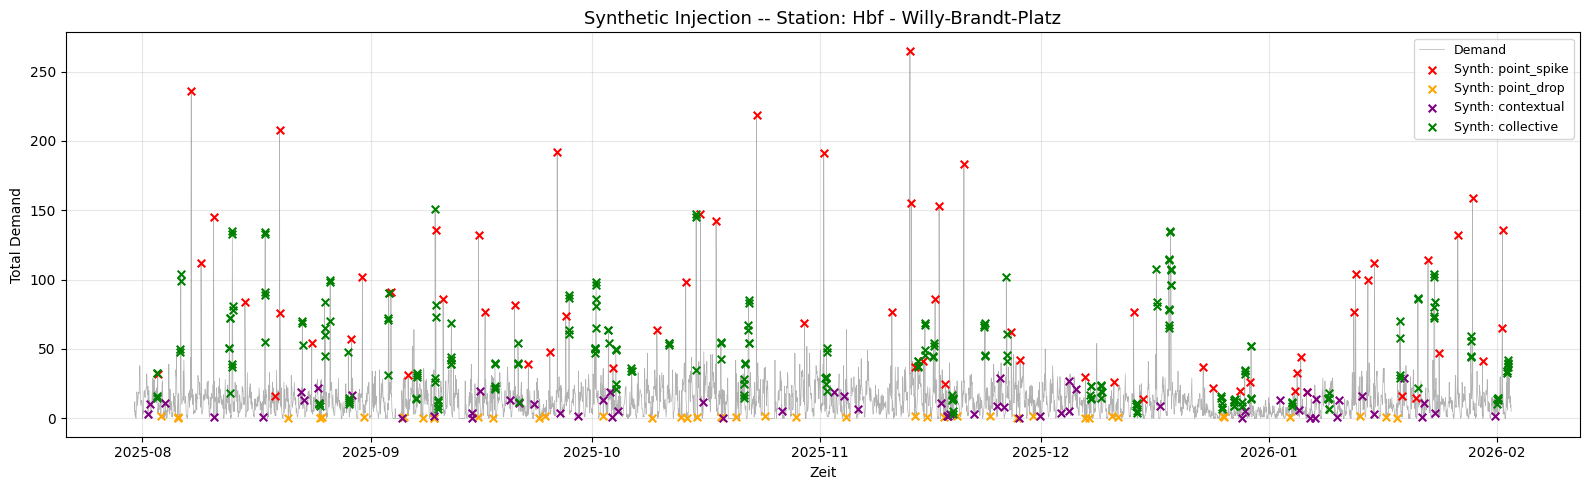

In [22]:
# ══════════════════════════════════════════════════════════════
# 5 -- Plausibilitaetsplot: Beispiel-Station mit Injection
# ══════════════════════════════════════════════════════════════
test_df = df_hd_injected[df_hd_injected["hour_ts"] >= val_end_hd].copy()

top_station = (
    test_df[test_df["synth_label"] == 1]
    .groupby("station_id").size()
    .sort_values(ascending=False).head(1)
)
if len(top_station) > 0:
    example_sid = top_station.index[0]
    station_data = test_df[test_df["station_id"] == example_sid].copy()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(station_data["hour_ts"], station_data["total_demand"],
            alpha=0.6, linewidth=0.5, color='gray', label='Demand')

    colors_map = {"point_spike": "red", "point_drop": "orange",
                  "contextual": "purple", "collective": "green"}
    for stype, color in colors_map.items():
        subset = station_data[station_data["synth_type"] == stype]
        if len(subset) > 0:
            ax.scatter(subset["hour_ts"], subset["total_demand"],
                       s=30, marker='x', color=color, label=f'Synth: {stype}', zorder=5)

    sname = station_data["station_name"].iloc[0] if "station_name" in station_data.columns else example_sid
    ax.set_title(f"Synthetic Injection -- Station: {sname}", fontsize=13)
    ax.set_xlabel("Zeit"); ax.set_ylabel("Total Demand")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{RUN_NAME}_injection_example.png", dpi=150, bbox_inches='tight')
    plt.show()


---
### Evaluation gegen synthetische Labels


In [23]:
# ══════════════════════════════════════════════════════════════
# 6 -- Evaluation gegen synthetische Labels (V12 erweitert)
# ══════════════════════════════════════════════════════════════
def evaluate_against_synthetic(
    model,
    df_injected: pd.DataFrame,
    scaler: StandardScaler,
    cfg,
    test_start: pd.Timestamp,
    experiment_name: str,
    verbose: bool = True
) -> Dict:
    ae_features        = cfg.ae_features
    ae_target_features = cfg.ae_target_features if cfg.ae_target_features is not None else cfg.ae_features

    df_ae = df_injected.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_ae = df_ae.dropna(subset=ae_features).copy()

    df_ae_scaled = df_ae.copy()
    df_ae_scaled[ae_features] = scaler.transform(df_ae[ae_features])

    for col in ["synth_label", "synth_type", "original_n_lends", "original_n_returns"]:
        if col in df_ae.columns:
            df_ae_scaled[col] = df_ae[col].values

    X_all, meta_all = make_sequences_with_window_labels(
        df_ae_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col="synth_label",
        synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    meta_all["is_test"] = meta_all["hour_ts"] >= test_start

    X_hat_all = predict_in_batches(model, X_all, batch_size=cfg.eval_batch_size)
    all_scores = compute_ae_scores_from_predictions(
        X_all,
        X_hat_all,
        input_features=ae_features,
        target_features=ae_target_features,
        score_features=cfg.ae_score_features,
        score_mode=cfg.score_mode,
        weighted_alpha_last=cfg.weighted_alpha_last,
    )
    meta_all["ae_score_raw"] = all_scores

    test_meta = meta_all[meta_all["is_test"]].copy()
    if len(test_meta) == 0:
        print("  WARNUNG: Keine Testdaten!")
        return {}

    results = {
        "experiment": experiment_name,
        "n_test": len(test_meta),
        "score_mode": cfg.score_mode,
        "target_features": ae_target_features,
        "input_features": ae_features,
    }

    y_true_win = test_meta["window_synth_label"].astype(int).values
    y_score    = test_meta["ae_score_raw"].values

    if verbose:
        n_synth_win = y_true_win.sum()
        n_synth_ls  = test_meta["synth_label"].astype(int).sum()
        print(f"  [{experiment_name}]")
        print(f"    Test-Sequenzen: {len(test_meta):,}")
        print(f"    Score-Mode: {cfg.score_mode}")
        print(f"    Reconstruction-Target: {ae_target_features}")
        print(f"    Window-Level Anomalien: {n_synth_win:,} ({n_synth_win/len(test_meta)*100:.2f}%)")
        print(f"    Last-Step Anomalien:    {n_synth_ls:,} ({n_synth_ls/len(test_meta)*100:.2f}%)")

    if len(np.unique(y_true_win)) > 1:
        results["window_pr_auc"]  = average_precision_score(y_true_win, y_score)
        results["window_roc_auc"] = roc_auc_score(y_true_win, y_score)

        prec_arr, rec_arr, thr_arr = precision_recall_curve(y_true_win, y_score)
        f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-10)
        best_idx = np.argmax(f1_arr)
        results["window_best_f1"]        = f1_arr[best_idx]
        results["window_best_precision"] = prec_arr[best_idx]
        results["window_best_recall"]    = rec_arr[best_idx]
        results["window_best_threshold"] = thr_arr[best_idx]
    else:
        results["window_pr_auc"] = results["window_roc_auc"] = results["window_best_f1"] = None

    y_true_ls = test_meta["synth_label"].astype(int).values
    if len(np.unique(y_true_ls)) > 1:
        results["laststep_pr_auc"]  = average_precision_score(y_true_ls, y_score)
        results["laststep_roc_auc"] = roc_auc_score(y_true_ls, y_score)

        prec_ls, rec_ls, thr_ls = precision_recall_curve(y_true_ls, y_score)
        f1_ls = 2 * prec_ls[:-1] * rec_ls[:-1] / (prec_ls[:-1] + rec_ls[:-1] + 1e-10)
        best_ls = np.argmax(f1_ls)
        results["laststep_best_f1"]        = f1_ls[best_ls]
        results["laststep_best_precision"] = prec_ls[best_ls]
        results["laststep_best_recall"]    = rec_ls[best_ls]
    else:
        results["laststep_pr_auc"] = results["laststep_roc_auc"] = results["laststep_best_f1"] = None

    results["per_type"] = {}
    if results.get("window_best_threshold") is not None:
        thr = results["window_best_threshold"]
        for atype in ["point_spike", "point_drop", "contextual", "collective"]:
            sub = test_meta[test_meta["window_synth_type"] == atype]
            if len(sub) > 0:
                detected = (sub["ae_score_raw"] >= thr).sum()
                results["per_type"][atype] = {
                    "n": len(sub),
                    "detected": int(detected),
                    "detection_rate": detected / len(sub)
                }

    if verbose:
        print("    --- Window-Level ---")
        print(f"    PR-AUC:  {results.get('window_pr_auc', 'N/A')}")
        print(f"    ROC-AUC: {results.get('window_roc_auc', 'N/A')}")
        if results.get("window_best_f1") is not None:
            print(f"    Best F1: {results['window_best_f1']:.4f} (P={results['window_best_precision']:.4f}, R={results['window_best_recall']:.4f})")
        print("    --- Last-Step ---")
        print(f"    PR-AUC:  {results.get('laststep_pr_auc', 'N/A')}")
        if results.get("laststep_best_f1") is not None:
            print(f"    Best F1: {results['laststep_best_f1']:.4f}")

    results["meta"] = test_meta
    return results


---
## Experiment 1: Score-Varianten

Getestet auf den starken V11-Kandidaten:
- `HD_Baseline`
- `ZeroShot_HD_Scaler`
- `HD_Only_25pct`

Verglichen werden:
- `last_step_mean` (V11-Status quo)
- `window_mean`
- `weighted_blend`


In [26]:
import copy


# ══════════════════════════════════════════════════════════════
# 7 -- Score-Varianten evaluieren
# ══════════════════════════════════════════════════════════════
ae_features = cfg.ae_features

df_hd_train_orig = df_hd[df_hd["hour_ts"] < train_end_hd].copy()
scaler_hd = StandardScaler()
scaler_hd.fit(df_hd_train_orig[ae_features].dropna())

score_models = {
    "HD_Baseline": (baseline_hd["model"], scaler_hd),
    "ZeroShot_HD_Scaler": (source_model, scaler_hd),
    "HD_Only_25pct": (hd_only_25["model"], scaler_hd),
}

score_variants = [
    ("last_step_mean", "score_current"),
    ("window_mean", "score_window_mean"),
    ("weighted_blend", "score_weighted_blend"),
]

synth_results = {}
score_variant_rows = []

print("="*70)
print("  EXPERIMENT 1 -- SCORE-VARIANTEN")
print("="*70)

for model_name, (model_obj, scaler_obj) in score_models.items():
    for score_mode, score_suffix in score_variants:
        cfg_eval = clone_cfg(cfg, score_mode=score_mode)
        exp_name = f"Exp1__{model_name}__{score_suffix}"
        print(f" --- {exp_name} ---")
        res = evaluate_against_synthetic(
            model_obj, df_hd_injected, scaler_obj, cfg_eval,
            val_end_hd, exp_name
        )
        synth_results[exp_name] = res
        score_variant_rows.append({
            "model_family": model_name,
            "score_variant": score_suffix,
            "Win_PR-AUC": res.get("window_pr_auc"),
            "Win_F1": res.get("window_best_f1"),
            "LS_PR-AUC": res.get("laststep_pr_auc"),
        })

score_variant_df = pd.DataFrame(score_variant_rows).sort_values(["model_family", "Win_PR-AUC"], ascending=[True, False])
print("Score-Varianten Uebersicht:")
print(score_variant_df.to_string(index=False, float_format="{:.4f}".format))
score_variant_df.to_csv(f"{RESULTS_DIR}/{RUN_NAME}_exp1_score_variants.csv", index=False)


  EXPERIMENT 1 -- SCORE-VARIANTEN
 --- Exp1__HD_Baseline__score_current ---
  [Exp1__HD_Baseline__score_current]
    Test-Sequenzen: 197,782
    Score-Mode: last_step_mean
    Reconstruction-Target: ['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
    Window-Level Anomalien: 53,010 (26.80%)
    Last-Step Anomalien:    5,064 (2.56%)
    --- Window-Level ---
    PR-AUC:  0.4352401290806055
    ROC-AUC: 0.6746877271409805
    Best F1: 0.4862 (P=0.3978, R=0.6249)
    --- Last-Step ---
    PR-AUC:  0.48020837164031754
    Best F1: 0.4995
 --- Exp1__HD_Baseline__score_window_mean ---
  [Exp1__HD_Baseline__score_window_mean]
    Test-Sequenzen: 197,782
    Score-Mode: window_mean
    Reconstruction-Target: ['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
    Window-Level Anomalien: 53,010 (26.80%)
    Last-Step Anomalien:    5,064 (2.56%)
    --- Window-Level ---
    PR-

---
## Experiment 2: Reconstruction Target

Vergleich:
- **Standard**: Rekonstruktion aller Input-Features
- **Demand-only**: Rekonstruktion nur von `n_lends`, `n_returns`

Getestet auf:
- `HD_Baseline`
- `ZeroShot_HD_Scaler`


In [27]:
# ══════════════════════════════════════════════════════════════
# 8 -- Reconstruction-Target testen
# ══════════════════════════════════════════════════════════════
print("="*70)
print("  EXPERIMENT 2 -- RECONSTRUCTION TARGET")
print("="*70)

cfg_demand_target = clone_cfg(cfg, ae_target_features=["n_lends", "n_returns"], score_mode="last_step_mean")

print(" [1/2] Source-Modell mit Demand-only Target trainieren...")
source_result_demand = run_ae_pipeline(
    df_ma, cfg_demand_target, train_end_ma, val_end_ma,
    experiment_name="Source_Mannheim_DemandTarget"
)

print(" [2/2] HD-Baseline mit Demand-only Target trainieren...")
baseline_hd_demand = run_ae_pipeline(
    df_hd, cfg_demand_target, train_end_hd, val_end_hd,
    experiment_name="HD_Baseline_DemandTarget"
)

for exp_name, model_obj, scaler_obj in [
    ("Exp2__HD_Baseline__demand_target", baseline_hd_demand["model"], scaler_hd),
    ("Exp2__ZeroShot_HD_Scaler__demand_target", source_result_demand["model"], scaler_hd),
]:
    print(f" --- {exp_name} ---")
    synth_results[exp_name] = evaluate_against_synthetic(
        model_obj,
        df_hd_injected,
        scaler_obj,
        cfg_demand_target,
        val_end_hd,
        exp_name
    )


  EXPERIMENT 2 -- RECONSTRUCTION TARGET
 [1/2] Source-Modell mit Demand-only Target trainieren...
────────────────────────────────────────────────────────────
  AE-PIPELINE: Source_Mannheim_DemandTarget
────────────────────────────────────────────────────────────
  Scaler: lokal gefittet auf 1,458,722 Trainings-Zeilen
  Sequenzen: (1981139, 24, 9)
  X_train: (1261111, 24, 9), Y_train: (1261111, 24, 2), X_val: (292816, 24, 9)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_3 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_3 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 2)          │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,042 (183.76 KB)

 Trainable params: 47,042 (183.76 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_3 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_3 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 2)          │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,042 (183.76 KB)

 Trainable params: 47,042 (183.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - loss: 0.3357 - val_loss: 0.3480 - learning_rate: 0.0010
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2891 - val_loss: 0.3238 - learning_rate: 0.0010
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2744 - val_loss: 0.3017 - learning_rate: 0.0010
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2586 - val_loss: 0.2781 - learning_rate: 0.0010
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2419 - val_loss: 0.2527 - learning_rate: 0.0010
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2277 - val_loss: 0.2405 - learning_rate: 0.0010
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2182 - val_loss: 0.2254 - learning_rate: 0.0010
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2113 - val_loss: 0.2209 - learning_rate: 0.0010
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2066 - val_loss: 0.2145 - learning_rate:

---
## Experiment 3: Ein einzelner Wetter-Test

Es wird **genau ein Wetter-Feature-Set** getestet:
- `weather_temp`
- `weather_precip`
- `weather_wind`

Getestet auf:
- `HD_Baseline`
- `ZeroShot_HD_Scaler`


In [28]:
# ══════════════════════════════════════════════════════════════
# 9 -- Wetter-Test
# ══════════════════════════════════════════════════════════════
print("="*70)
print("  EXPERIMENT 3 -- WETTER-TEST")
print("="*70)

weather_hourly = load_hourly_weather_features(weather_path, station_id=292348, agg_minutes=cfg.aggregation_minutes)
weather_feature_cols = [c for c in weather_hourly.columns if c != "hour_ts"]

if len(weather_feature_cols) == 0:
    print("Keine Wetter-Features verfuegbar -- Experiment 3 wird uebersprungen.")
else:
    df_ma_weather = attach_weather_features(df_ma, weather_hourly)
    df_hd_weather = attach_weather_features(df_hd, weather_hourly)

    cfg_weather = clone_cfg(
        cfg,
        ae_features=cfg.ae_features + weather_feature_cols,
        ae_target_features=None,
        score_mode="last_step_mean"
    )

    print(" [1/2] Source-Modell mit Wetter trainieren...")
    source_result_weather = run_ae_pipeline(
        df_ma_weather, cfg_weather, train_end_ma, val_end_ma,
        experiment_name="Source_Mannheim_Weather"
    )

    print(" [2/2] HD-Baseline mit Wetter trainieren...")
    baseline_hd_weather = run_ae_pipeline(
        df_hd_weather, cfg_weather, train_end_hd, val_end_hd,
        experiment_name="HD_Baseline_Weather"
    )

    df_hd_injected_weather = attach_weather_features(df_hd_injected, weather_hourly)
    scaler_hd_weather = StandardScaler()
    scaler_hd_weather.fit(df_hd_weather.loc[df_hd_weather["hour_ts"] < train_end_hd, cfg_weather.ae_features].dropna())

    for exp_name, model_obj, scaler_obj in [
        ("Exp3__HD_Baseline__weather", baseline_hd_weather["model"], scaler_hd_weather),
        ("Exp3__ZeroShot_HD_Scaler__weather", source_result_weather["model"], scaler_hd_weather),
    ]:
        print(f" --- {exp_name} ---")
        synth_results[exp_name] = evaluate_against_synthetic(
            model_obj, df_hd_injected_weather, scaler_obj, cfg_weather,
            val_end_hd, exp_name
        )


  EXPERIMENT 3 -- WETTER-TEST
  Wetter-Features geladen: ['hour_ts', 'weather_temp', 'weather_precip', 'weather_wind']
  Wetter-Zeilen: 24,913
  Wetter-Merge abgeschlossen: ['weather_temp', 'weather_precip', 'weather_wind']
  Wetter-Merge abgeschlossen: ['weather_temp', 'weather_precip', 'weather_wind']
 [1/2] Source-Modell mit Wetter trainieren...
────────────────────────────────────────────────────────────
  AE-PIPELINE: Source_Mannheim_Weather
────────────────────────────────────────────────────────────
  Scaler: lokal gefittet auf 1,458,722 Trainings-Zeilen
  Sequenzen: (1981139, 24, 12)
  X_train: (1261111, 24, 12), Y_train: (1261111, 24, 12), X_val: (292816, 24, 12)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_3 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_3 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 12)         │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,756 (186.55 KB)

 Trainable params: 47,756 (186.55 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_3 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_3 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 12)         │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,756 (186.55 KB)

 Trainable params: 47,756 (186.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - loss: 0.5491 - val_loss: 0.4366 - learning_rate: 0.0010
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3991 - val_loss: 0.2724 - learning_rate: 0.0010
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3018 - val_loss: 0.2278 - learning_rate: 0.0010
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.2712 - val_loss: 0.2145 - learning_rate: 0.0010
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.2574 - val_loss: 0.2065 - learning_rate: 0.0010
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2470 - val_loss: 0.1950 - learning_rate: 0.0010
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.2367 - val_loss: 0.1841 - learning_rate: 0.0010
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2292 - val_loss: 0.1791 - learning_rate: 0.0010
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.2239 - val_loss: 0.1768 - learning_rate:

In [29]:
# ══════════════════════════════════════════════════════════════
# 10 -- Gesamtergebnistabelle
# ══════════════════════════════════════════════════════════════
rows = []
for name, res in synth_results.items():
    if not res:
        continue

    if name.startswith("Exp1__"):
        block = "Exp1_ScoreVariants"
    elif name.startswith("Exp2__"):
        block = "Exp2_ReconTarget"
    elif name.startswith("Exp3__"):
        block = "Exp3_Weather"
    else:
        block = "Other"

    row = {
        "Block": block,
        "Experiment": name,
        "ScoreMode": res.get("score_mode"),
        "TargetFeatures": ", ".join(res.get("target_features", [])) if res.get("target_features") else None,
        "Win_PR-AUC": res.get("window_pr_auc"),
        "Win_ROC-AUC": res.get("window_roc_auc"),
        "Win_Best_F1": res.get("window_best_f1"),
        "Win_Precision": res.get("window_best_precision"),
        "Win_Recall": res.get("window_best_recall"),
        "LS_PR-AUC": res.get("laststep_pr_auc"),
        "LS_Best_F1": res.get("laststep_best_f1"),
    }
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        info = res.get("per_type", {}).get(atype, {})
        row[f"DR_{atype}"] = info.get("detection_rate")
    rows.append(row)

synth_df = pd.DataFrame(rows).sort_values(["Block", "Win_PR-AUC"], ascending=[True, False]).reset_index(drop=True)
print("" + "="*110)
print("  V12 ERGEBNISSE -- Gezielte Zusatzexperimente")
print("="*110)
print(synth_df[["Block", "Experiment", "Win_PR-AUC", "Win_Best_F1", "LS_PR-AUC", "LS_Best_F1"]].to_string(index=False, float_format="{:.4f}".format))

synth_df.to_csv(f"{RESULTS_DIR}/{RUN_NAME}_synthetic_results.csv", index=False)
print(f" Gespeichert: {RESULTS_DIR}/{RUN_NAME}_synthetic_results.csv")


  V12 ERGEBNISSE -- Gezielte Zusatzexperimente
             Block                                     Experiment  Win_PR-AUC  Win_Best_F1  LS_PR-AUC  LS_Best_F1
Exp1_ScoreVariants    Exp1__ZeroShot_HD_Scaler__score_window_mean      0.7063       0.6572     0.0787      0.1475
Exp1_ScoreVariants         Exp1__HD_Only_25pct__score_window_mean      0.7046       0.6530     0.0801      0.1504
Exp1_ScoreVariants           Exp1__HD_Baseline__score_window_mean      0.7017       0.6540     0.0787      0.1473
Exp1_ScoreVariants Exp1__ZeroShot_HD_Scaler__score_weighted_blend      0.5867       0.5946     0.4048      0.4263
Exp1_ScoreVariants      Exp1__HD_Only_25pct__score_weighted_blend      0.5862       0.5974     0.4217      0.4388
Exp1_ScoreVariants        Exp1__HD_Baseline__score_weighted_blend      0.5851       0.5947     0.4154      0.4353
Exp1_ScoreVariants               Exp1__HD_Baseline__score_current      0.4352       0.4862     0.4802      0.4995
Exp1_ScoreVariants             Exp1__HD_O

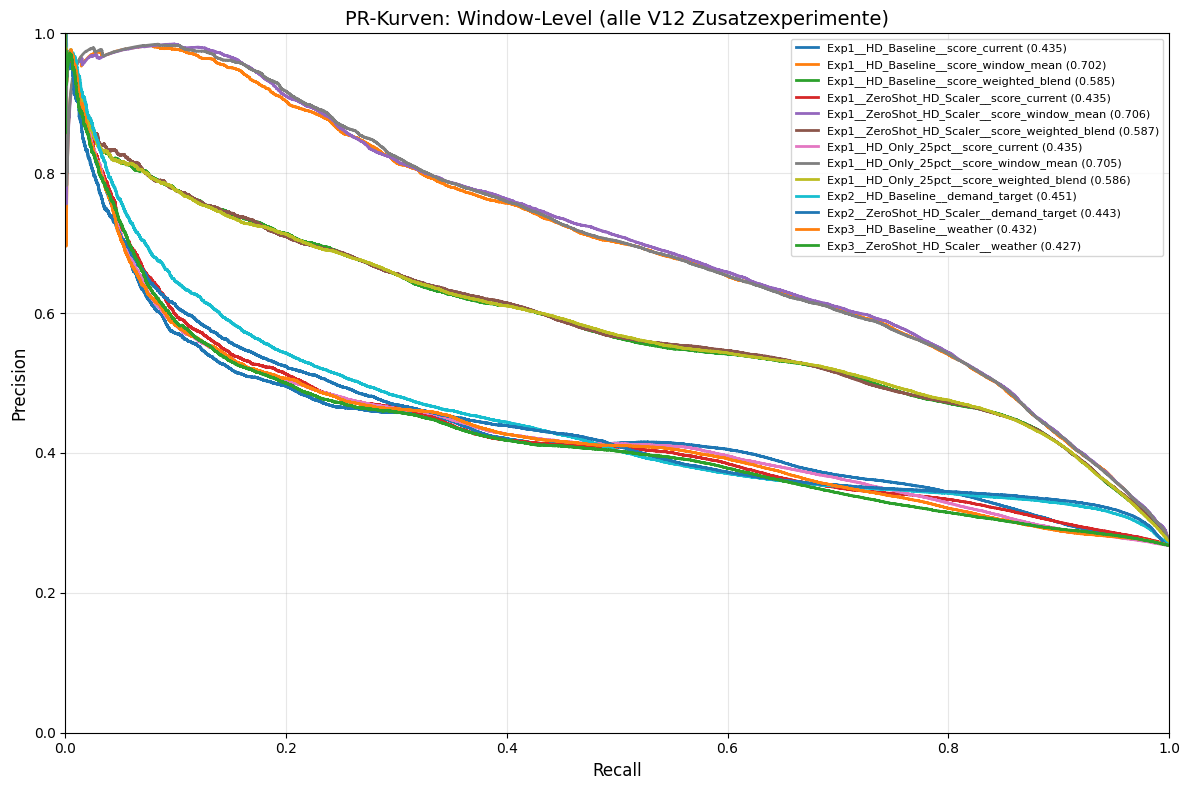

In [30]:
# ══════════════════════════════════════════════════════════════
# 11 -- PR-Kurven (Window-Level)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 8))

for name, res in synth_results.items():
    if not res or "meta" not in res:
        continue
    test_meta = res["meta"]
    y_true  = test_meta["window_synth_label"].astype(int).values
    y_score = test_meta["ae_score_raw"].values

    valid = np.isfinite(y_score)
    if valid.sum() == 0 or len(np.unique(y_true[valid])) < 2:
        continue

    prec, rec, _ = precision_recall_curve(y_true[valid], y_score[valid])
    pr_auc = average_precision_score(y_true[valid], y_score[valid])
    ax.plot(rec, prec, linewidth=2, label=f"{name} ({pr_auc:.3f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("PR-Kurven: Window-Level (alle V12 Zusatzexperimente)", fontsize=14)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{RUN_NAME}_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()


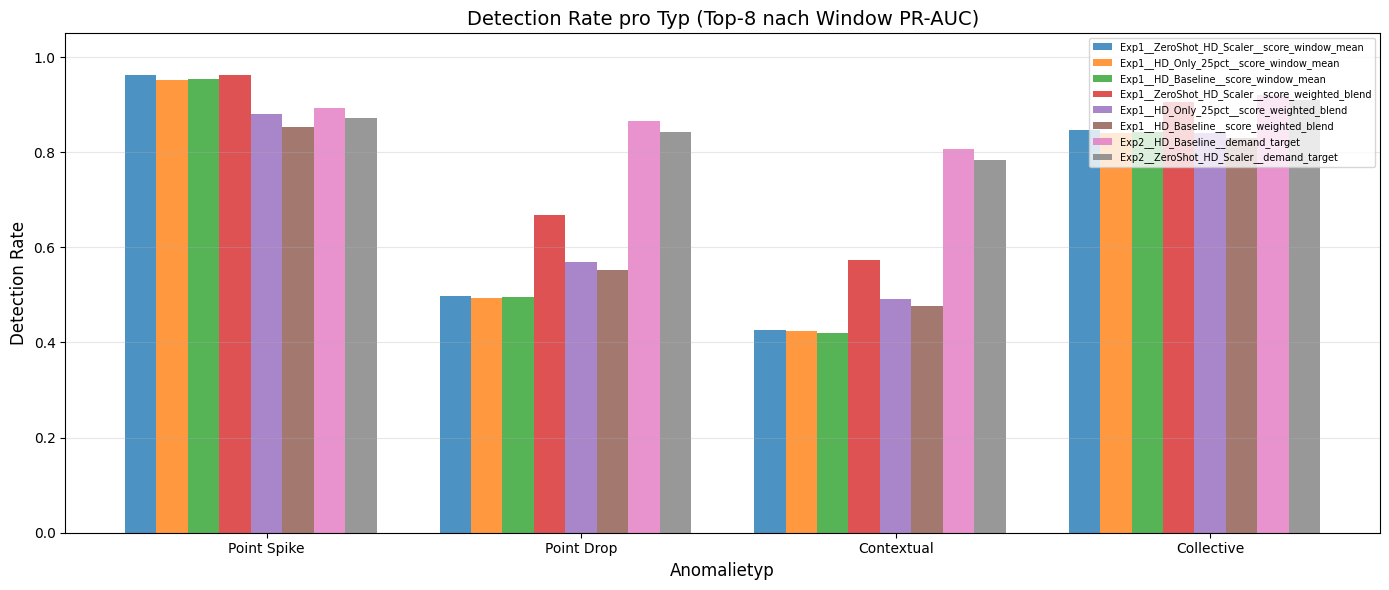

In [31]:
# ══════════════════════════════════════════════════════════════
# 12 -- Detection Rate pro Anomalietyp (Top-Experimente)
# ══════════════════════════════════════════════════════════════
top_df = synth_df.sort_values("Win_PR-AUC", ascending=False).head(8)
fig, ax = plt.subplots(figsize=(14, 6))

types = ["point_spike", "point_drop", "contextual", "collective"]
experiments = top_df["Experiment"].tolist()

x = np.arange(len(types))
width = 0.8 / max(len(experiments), 1)

for i, exp_name in enumerate(experiments):
    rates = []
    for t in types:
        info = synth_results[exp_name].get("per_type", {}).get(t, {})
        rates.append(info.get("detection_rate", 0))
    ax.bar(x + i * width, rates, width, label=exp_name, alpha=0.8)

ax.set_xlabel("Anomalietyp", fontsize=12)
ax.set_ylabel("Detection Rate", fontsize=12)
ax.set_title("Detection Rate pro Typ (Top-8 nach Window PR-AUC)", fontsize=14)
ax.set_xticks(x + width * len(experiments) / 2)
ax.set_xticklabels([t.replace("_", " ").title() for t in types])
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{RUN_NAME}_detection_rates.png", dpi=150, bbox_inches='tight')
plt.show()


---
## Strategie B: Event-basierte Plausibilitaetspruefung


In [32]:
# ══════════════════════════════════════════════════════════════
# 11 -- Wetter- und Eventdaten laden (angepasst an Datenstruktur)
# ══════════════════════════════════════════════════════════════

# Mannheim Wetterstation (auch fuer Heidelberg -- raeumliche Naehe)
WEATHER_STATION_ID = 292348

# --- Wetter laden ---
weather_files = glob.glob(f'{weather_path}/**/*.parquet', recursive=True)
if not weather_files:
    weather_files = glob.glob(f'{weather_path}/*.parquet')

weather = None
if weather_files:
    weather_dfs = []
    for wf in weather_files:
        try:
            weather_dfs.append(pd.read_parquet(wf))
        except Exception as e:
            print(f"  Fehler: {wf}: {e}")
    if weather_dfs:
        weather = pd.concat(weather_dfs, ignore_index=True)
        # Nur unsere Wetterstation
        weather = weather[weather["location_id"] == WEATHER_STATION_ID].copy()
        weather["timestamp"] = pd.to_datetime(weather["timestamp"], utc=True)
        weather["date"] = weather["timestamp"].dt.date
        print(f"  Wetter geladen: {len(weather):,} Zeilen (Station {WEATHER_STATION_ID})")
        print(f"  Zeitraum: {weather['date'].min()} bis {weather['date'].max()}")
        print(f"  Spalten: {list(weather.columns)}")

if weather is None:
    print("  WARNUNG: Keine Wetterdaten geladen!")

# --- Feiertage laden ---
# Spalten: name, start_date, federal_state_name, end_date, type
# type = 'public_holiday'
holiday_files = glob.glob(f'{holidays_path}/**/*.parquet', recursive=True)
if not holiday_files:
    holiday_files = glob.glob(f'{holidays_path}/*.parquet')

holidays = None
if holiday_files:
    holidays = pd.concat([pd.read_parquet(f) for f in holiday_files], ignore_index=True)
    # Nur Baden-Wuerttemberg (Mannheim + Heidelberg)
    holidays = holidays[holidays["federal_state_name"] == "Baden-Württemberg"].copy()
    holidays["start_date"] = pd.to_datetime(holidays["start_date"])
    holidays["end_date"]   = pd.to_datetime(holidays["end_date"])
    print(f"  Feiertage geladen: {len(holidays)} Eintraege (BW)")

# --- Ferien laden ---
# Spalten: name, start_date, federal_state_name, end_date, type
# type = 'school_vacation'
vacation_files = glob.glob(f'{vacations_path}/**/*.parquet', recursive=True)
if not vacation_files:
    vacation_files = glob.glob(f'{vacations_path}/*.parquet')

vacations = None
if vacation_files:
    vacations = pd.concat([pd.read_parquet(f) for f in vacation_files], ignore_index=True)
    vacations = vacations[vacations["federal_state_name"] == "Baden-Württemberg"].copy()
    vacations["start_date"] = pd.to_datetime(vacations["start_date"])
    vacations["end_date"]   = pd.to_datetime(vacations["end_date"])
    print(f"  Ferien geladen: {len(vacations)} Eintraege (BW)")

print("\nDaten geladen.")


  Wetter geladen: 149,473 Zeilen (Station 292348)
  Zeitraum: 2023-04-01 bis 2026-02-02
  Spalten: ['location_id', 'timestamp', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'wind_direction', 'date']
  Feiertage geladen: 176 Eintraege (BW)
  Ferien geladen: 20 Eintraege (BW)

Daten geladen.


In [33]:
# ══════════════════════════════════════════════════════════════
# 12 -- Event-Tage identifizieren
# ══════════════════════════════════════════════════════════════

event_days = {}  # date -> set of event types

# --- Feiertage ---
if holidays is not None:
    for _, row in holidays.iterrows():
        for d in pd.date_range(row["start_date"], row["end_date"]):
            dt = d.date()
            if dt not in event_days:
                event_days[dt] = set()
            event_days[dt].add("feiertag")
    print(f"Feiertage: {sum(1 for v in event_days.values() if 'feiertag' in v)} Tage")

# --- Ferien ---
if vacations is not None:
    for _, row in vacations.iterrows():
        for d in pd.date_range(row["start_date"], row["end_date"]):
            dt = d.date()
            if dt not in event_days:
                event_days[dt] = set()
            event_days[dt].add("ferien")
    print(f"Ferientage: {sum(1 for v in event_days.values() if 'ferien' in v)} Tage")

# --- Extremwetter ---
if weather is not None:
    # Tagesaggregate
    daily_weather = weather.groupby("date").agg(
        temp_max=("temperature", "max"),
        temp_min=("temperature", "min"),
        precip_sum=("precipitation", "sum"),
        wind_max=("wind_speed", "max"),
    ).reset_index()

    # Schwellwerte fuer Extremwetter
    extreme_hot  = daily_weather[daily_weather["temp_max"] >= 33]["date"]
    extreme_cold = daily_weather[daily_weather["temp_min"] <= -3]["date"]
    heavy_rain   = daily_weather[daily_weather["precip_sum"] >= 15]["date"]  # >15mm/Tag
    strong_wind  = daily_weather[daily_weather["wind_max"] >= 60]["date"]    # >60 km/h

    for dt in extreme_hot:
        event_days.setdefault(dt, set()).add("hitze")
    for dt in extreme_cold:
        event_days.setdefault(dt, set()).add("kaelte")
    for dt in heavy_rain:
        event_days.setdefault(dt, set()).add("starkregen")
    for dt in strong_wind:
        event_days.setdefault(dt, set()).add("sturm")

    print(f"Extremwetter: {len(extreme_hot)} Hitze, {len(extreme_cold)} Kaelte, "
          f"{len(heavy_rain)} Starkregen, {len(strong_wind)} Sturm")

# Zusammenfassung
all_event_dates = set(event_days.keys())
print(f"\nGesamt Event-Tage: {len(all_event_dates)}")

# Aufschluesselung
all_types = set()
for v in event_days.values():
    all_types.update(v)
for t in sorted(all_types):
    n = sum(1 for v in event_days.values() if t in v)
    print(f"  {t}: {n} Tage")


Feiertage: 167 Tage
Ferientage: 277 Tage
Extremwetter: 179 Hitze, 111 Kaelte, 23 Starkregen, 0 Sturm

Gesamt Event-Tage: 617
  feiertag: 167 Tage
  ferien: 277 Tage
  hitze: 179 Tage
  kaelte: 111 Tage
  starkregen: 23 Tage


In [34]:
# ══════════════════════════════════════════════════════════════
# 13 -- Event-Korrelation: differenziert nach Event-Typ
# ══════════════════════════════════════════════════════════════
def event_correlation_analysis(
    meta_df: pd.DataFrame,
    event_days: Dict,
    test_start: pd.Timestamp,
    label_col: str,
    experiment_name: str = ""
) -> pd.DataFrame:
    test = meta_df[meta_df["hour_ts"] >= test_start].copy()
    if len(test) == 0:
        print(f"  WARNUNG: Keine Testdaten fuer {experiment_name}")
        return pd.DataFrame()

    test["date"] = pd.to_datetime(test["hour_ts"]).dt.date

    if label_col not in test.columns:
        print(f"  WARNUNG: {label_col} nicht in DataFrame fuer {experiment_name}!")
        return pd.DataFrame()

    if test[label_col].dtype == object:
        test["is_anomaly"] = test[label_col].isin(["anomal_high", "anomal_low"])
    else:
        test["is_anomaly"] = test[label_col].fillna(0).astype(int).astype(bool)

    all_event_dates = set(event_days.keys())
    test["is_any_event"] = test["date"].isin(all_event_dates)

    rate_event  = test.loc[test["is_any_event"], "is_anomaly"].mean()
    rate_normal = test.loc[~test["is_any_event"], "is_anomaly"].mean()

    rate_event = 0.0 if pd.isna(rate_event) else float(rate_event)
    rate_normal = 0.0 if pd.isna(rate_normal) else float(rate_normal)
    lift_total = rate_event / (rate_normal + 1e-10)

    rows = [
        {"experiment": experiment_name, "label_col": label_col, "event_type": "kein_event", "anomaly_rate": rate_normal, "lift": 1.0,
         "n_days": int(test.loc[~test["is_any_event"], "date"].nunique())},
        {"experiment": experiment_name, "label_col": label_col, "event_type": "any_event", "anomaly_rate": rate_event, "lift": lift_total,
         "n_days": int(test.loc[test["is_any_event"], "date"].nunique())}
    ]

    all_types = sorted({etype for v in event_days.values() for etype in v})
    for etype in all_types:
        etype_dates = {dt for dt, types in event_days.items() if etype in types}
        is_etype = test["date"].isin(etype_dates)
        if is_etype.sum() == 0:
            continue
        rate = test.loc[is_etype, "is_anomaly"].mean()
        rate = 0.0 if pd.isna(rate) else float(rate)
        lift = rate / (rate_normal + 1e-10)
        rows.append({
            "experiment": experiment_name,
            "label_col": label_col,
            "event_type": etype,
            "anomaly_rate": rate,
            "lift": lift,
            "n_days": int(test.loc[is_etype, "date"].nunique())
        })
    return pd.DataFrame(rows)


if len(event_days) > 0:
    print("=" * 70)
    print("  EVENT-BASIERTE PLAUSIBILITAETSPRUEFUNG")
    print("=" * 70)

    event_results = []

    if "meta_all_seq" in baseline_hd:
        if "label_eval" in baseline_hd["meta_all_seq"].columns:
            event_results.append(
                event_correlation_analysis(
                    baseline_hd["meta_all_seq"],
                    event_days,
                    val_end_hd,
                    label_col="label_eval",
                    experiment_name="HD_Baseline_stat_labels"
                )
            )
        if "ae_pred_station" in baseline_hd["meta_all_seq"].columns:
            event_results.append(
                event_correlation_analysis(
                    baseline_hd["meta_all_seq"],
                    event_days,
                    val_end_hd,
                    label_col="ae_pred_station",
                    experiment_name="HD_Baseline_ae_pred"
                )
            )

    for exp_name, res in synth_results.items():
        if not res or "meta" not in res:
            continue
        meta_df = res["meta"].copy()
        if "window_synth_label" in meta_df.columns:
            event_results.append(
                event_correlation_analysis(
                    meta_df, event_days, val_end_hd,
                    label_col="window_synth_label",
                    experiment_name=f"{exp_name}_window_synth"
                )
            )
        if "synth_label" in meta_df.columns:
            event_results.append(
                event_correlation_analysis(
                    meta_df, event_days, val_end_hd,
                    label_col="synth_label",
                    experiment_name=f"{exp_name}_laststep_synth"
                )
            )

    if event_results:
        event_df_all = pd.concat(event_results, ignore_index=True)
        event_df_all.to_csv(f"{RESULTS_DIR}/{RUN_NAME}_event_correlation.csv", index=False)
        print(f" Gespeichert: {RESULTS_DIR}/{RUN_NAME}_event_correlation.csv")


  EVENT-BASIERTE PLAUSIBILITAETSPRUEFUNG
 Gespeichert: /content/drive/MyDrive/BA_Colab/data/v12_targeted_transfer/v12_targeted_transfer_event_correlation.csv


In [35]:
# ══════════════════════════════════════════════════════════════
# 14 -- Zusammenfassung
# ══════════════════════════════════════════════════════════════
summary = {
    "run_name": RUN_NAME,
    "config_base": asdict(cfg),
    "synthetic_results": {
        k: {key: val for key, val in v.items() if key != "meta"}
        for k, v in synth_results.items() if v
    },
}

with open(f"{RESULTS_DIR}/{RUN_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("="*70)
print("  V12 ABGESCHLOSSEN")
print("="*70)
print(f"  Ergebnisse: {RESULTS_DIR}/")
print(f"    {RUN_NAME}_exp1_score_variants.csv")
print(f"    {RUN_NAME}_synthetic_results.csv")
print(f"    {RUN_NAME}_pr_curves.png")
print(f"    {RUN_NAME}_detection_rates.png")
print(f"    {RUN_NAME}_event_correlation.csv")
print(f"    {RUN_NAME}_summary.json")


  V12 ABGESCHLOSSEN
  Ergebnisse: /content/drive/MyDrive/BA_Colab/data/v12_targeted_transfer/
    v12_targeted_transfer_exp1_score_variants.csv
    v12_targeted_transfer_synthetic_results.csv
    v12_targeted_transfer_pr_curves.png
    v12_targeted_transfer_detection_rates.png
    v12_targeted_transfer_event_correlation.csv
    v12_targeted_transfer_summary.json


---
## Diskussionspunkte fuer die BA

- Verbessern Score-Varianten die Trennschaerfe staerker als Architektur-Skalierung?
- Reicht Demand-only-Rekonstruktion, um die Task naeherr an die eigentliche AD-Zielgroesse zu bringen?
- Liefern Wetterfeatures echten Mehrwert oder erklaeren die bestehenden Zeit-/Saisonalitaetsfeatures bereits den Grossteil?
- Warum ist Zero-Shot bereits so stark und warum bleibt der Fine-Tuning-Gewinn klein?


Jetzt mach ich noch ne Nicht-DL-Baseline zum Vergleich (iForest).
Und dann gehen wir zu Multi City